# DLENT-RT — Phase 0 Diagnostics

Understand the historical trace's distributions, validate the on-the-fly bid
synthesis and the energy/grid cost model, and inspect Phase 0's per-type
statistics, normalized objectives, and LP-RS admission oracle for the
configuration set in `OVERRIDES` below.

Sections: 0. Setup and configuration &middot; 1. Bid synthesis &middot;
2. Energy model and grid data &middot; 3. Phase 0 full output &middot;
4. Objective analysis &middot; 5. Order of magnitude across 20 seeds.

## Section 0: Setup and Configuration

In [1]:
import sys, warnings, dataclasses, random
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.simplefilter("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from dlent_rt.config import default_config
from dlent_rt.data import load_dataset
from dlent_rt.phase0 import (run_phase0, _compute_job_energy,
    _compute_job_power, _synthesize_bids, _lookup_grid)
from dlent_rt.bid import (synthesize_uniform, synthesize_lognormal,
    UniformBidParams, LognormalBidParams, compute_phi_tilde,
    MyersonModel, fit_myerson)
from dlent_rt.lp_oracle import solve_lp_rs
from dlent_rt.energy import load_grid_data
from dlent_rt.grid import ValuationGrid, build_valuation_grid

plt.rcParams["figure.figsize"] = (13, 3.6)
plt.rcParams["figure.dpi"] = 110

In [2]:
OVERRIDES = {
    "data.batch_csv": "../data/batch_may2019_30k.csv",
    "data.grid_csv":  "../data/grid_data_may_2019.csv",
    "data.n0":        10000,
    # --- capacity ---
    "capacity.mode":                    "fraction_of_concurrency_quantile",
    "capacity.fraction":                0.30,
    "capacity.concurrency_quantile":    0.80,
    # --- bid ---
    "bid.strategy":        "uniform",
    "bid.base_utility":    100.0,
    "bid.gamma1":          0.01,
    "bid.gamma2":          0.002,
    # --- normalization ---
    "normalization.strategy":         "common_currency",
    "normalization.carbon_tax_per_kg": 19.0,
    # --- objective weights ---
    "objective.lambda1": 0.3,
    "objective.lambda2": 0.3,
    "objective.lambda3": 0.3,
    # --- grid ---
    "grid.k_star":   128,
    "grid.space":    "v",
    "grid.spacing":  "geometric",
    # --- scalarization ---
    "scalarization.method": "linear",
}

def _replace_path(obj, path, value):
    if len(path) == 1:
        return dataclasses.replace(obj, **{path[0]: value})
    head, rest = path[0], path[1:]
    child = _replace_path(getattr(obj, head), rest, value)
    return dataclasses.replace(obj, **{head: child})

def apply_overrides(cfg, overrides: dict):
    """Apply {'a.b.c': value, ...} on top of cfg via recursive dataclasses.replace."""
    for dotted_key, value in overrides.items():
        cfg = _replace_path(cfg, dotted_key.split("."), value)
    return cfg

def print_config(c):
    """Print every config field, section by section, up to two levels deep."""
    for f in dataclasses.fields(c):
        val = getattr(c, f.name)
        if dataclasses.is_dataclass(val):
            print(f"[{f.name}]")
            for sf in dataclasses.fields(val):
                sval = getattr(val, sf.name)
                if dataclasses.is_dataclass(sval):
                    print(f"  {sf.name}:")
                    for ssf in dataclasses.fields(sval):
                        print(f"    {ssf.name} = {getattr(sval, ssf.name)}")
                else:
                    print(f"  {sf.name} = {sval}")
        else:
            print(f"{f.name} = {val}")
    print()

In [3]:
cfg = apply_overrides(default_config(), OVERRIDES).validate()

print("=== active configuration ===")
print_config(cfg)

ds = load_dataset(cfg)

print(f"H jobs:      {ds.H.n}")
print(f"stream jobs: {ds.stream.n}")
print(f"T (ticks):   {ds.T:,}")
print(f"H time range:     {ds.H.datetime.min()} -> {ds.H.datetime.max()}")
print(f"stream starts at: {ds.stream.datetime.min()}")
print(f"capacity: {np.round(ds.capacity, 3)}  (resources={ds.resources})")

h_hours = pd.to_datetime(ds.H.datetime).hour
print("\nH jobs per hour of day (stratification check):")
print(pd.Series(h_hours).value_counts().sort_index().to_string())

=== active configuration ===
[run]
  name = default
  seed = 42
  output_dir = runs
  log_level = INFO
[data]
  batch_csv = ../data/batch_may2019_30k.csv
  grid_csv = ../data/grid_data_may_2019.csv
  n0 = 10000
  columns:
    collection_id = collection_id
    datetime = request_time
    priority = priority
    scheduling_class = scheduling_class
    requested_cpu = CPU
    requested_ram = RAM
    duration_hours = duration
[time]
  step_semantics = real_tick
  tick_seconds = 1.0
  d_max_quantile = 1.0
  d_max_horizon_fraction = 0.05
  d_max_ratio_abort = 0.1
  duration_floor_hours = 0.016667
[hardware]
  n_profiles = 32
  method = kmeans
  log_space = True
  fit_on = full
  hw_floor = 1e-05
[outliers]
  policy = drop
  a_max_quantile = 0.9
  d_max_quantile = 0.9
  xi_warn_threshold = 0.1
[capacity]
  mode = fraction_of_concurrency_quantile
  fraction = 0.3
  concurrency_quantile = 0.8
  absolute:
    cpu = None
    ram = None
[energy_model]
  spec_cpu_core = 64
  spec_ram_gb = 256
  p_c

## Section 1: Bid Synthesis

The uniform bid model draws `v ~ U[Low, High]` with `Low = cost_base` and
`High = (1 + 2M) * cost_base`, `M = 1 + log(1 + priority)`. For a uniform
distribution, the Myerson virtual value has the closed form
`phi(v) = 2v - High` (Myerson 1981, Thm. 2). The fraction of `phi < 0` equals
`(High/2 - Low) / (High - Low)`, a ratio that depends only on `M` — i.e. only
on the priority mix — because `cost_base` cancels out of both `Low` and
`High`. That is why `phi < 0` for roughly a third of jobs regardless of
`base_utility`, `gamma1`, or `gamma2`.

,sigma,base_utility,bid_min,bid_max,bid_mean,phi<0%,phi_mean
0,0.1,100.0,1.0693,116.0362,11.4490,4.7977,6.9713
1,0.3,100.0,0.4270,185.6039,11.4393,17.2977,2.3104
2,0.5,100.0,0.1639,340.6312,11.4500,30.2584,0.5833


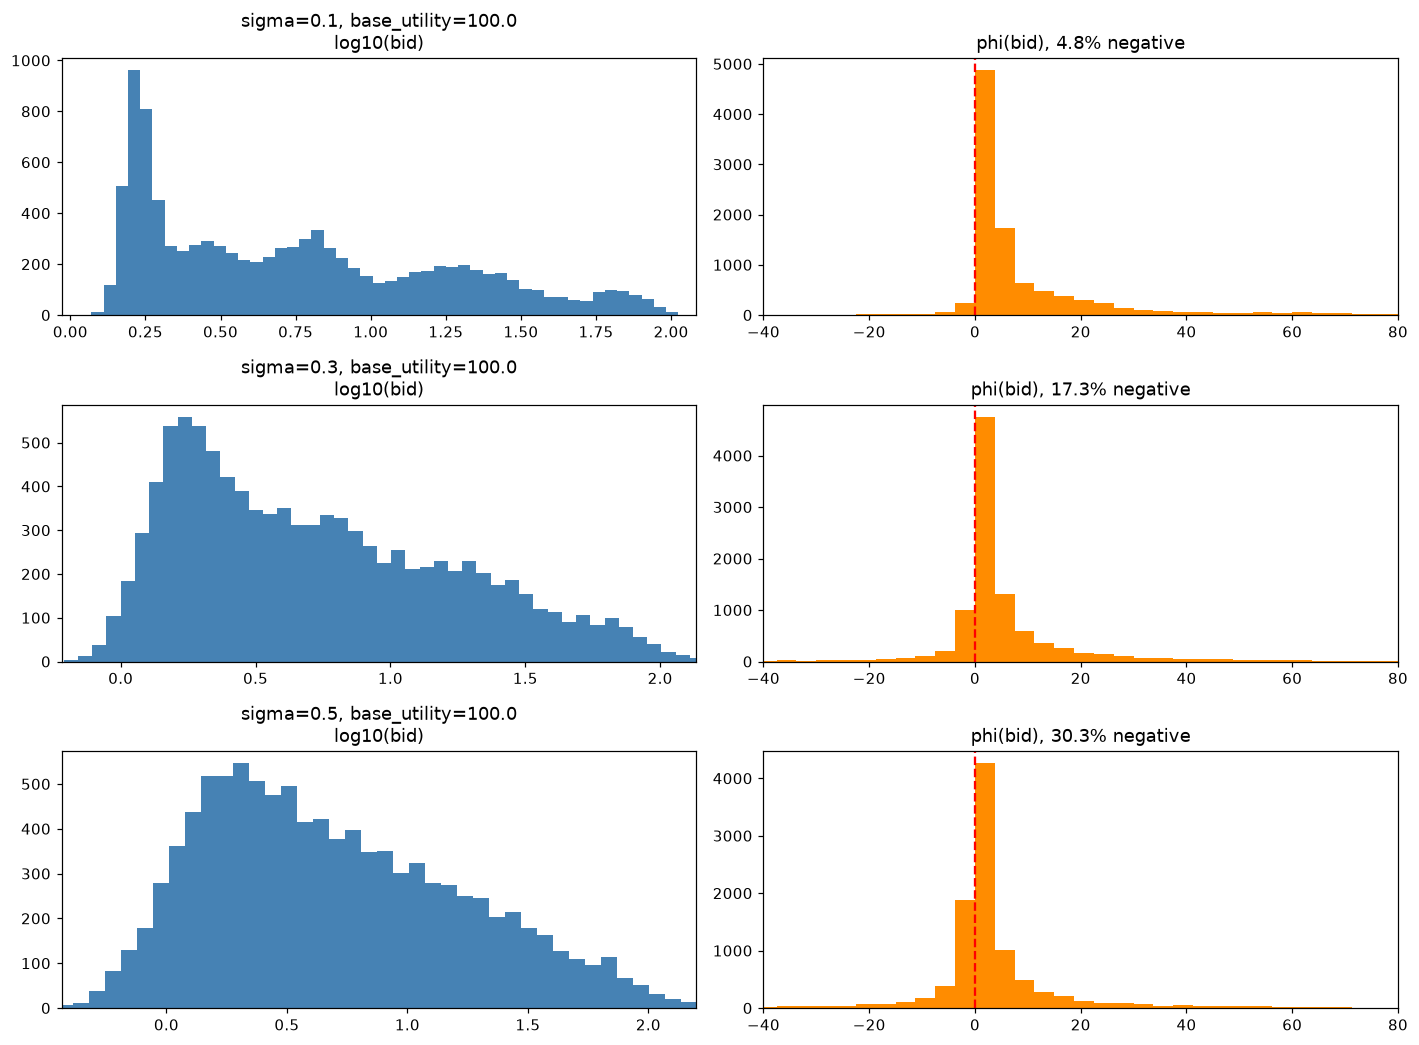

In [4]:
# Lognormal bid synthesis across a small grid of (sigma, base_utility)
LOGNORMAL_CONFIGS = [
    {"sigma": 0.1,  "base_utility": 100.0},
    {"sigma": 0.3,  "base_utility": 100.0},
    {"sigma": 0.5,  "base_utility": 100.0},
]

rows = []
lognormal_bids = []
for lc in LOGNORMAL_CONFIGS:
    params = LognormalBidParams(
        sigma=lc["sigma"], base_utility=lc["base_utility"],
        gamma1=cfg.bid.gamma1, gamma2=cfg.bid.gamma2,
        spec_cpu_core=cfg.energy_model.spec_cpu_core,
        spec_ram_gb=cfg.energy_model.spec_ram_gb,
    )
    b = synthesize_lognormal(
        ds.H.A[:, 0], ds.H.A[:, 1], ds.H.duration_hours,
        params, np.random.default_rng(42),
    )
    lognormal_bids.append((lc, b))
    rows.append({
        "sigma": lc["sigma"], "base_utility": lc["base_utility"],
        "bid_min": b.v_rate.min(), "bid_max": b.v_rate.max(),
        "bid_mean": b.v_rate.mean(),
        "phi<0%": 100 * (b.phi_rate < 0).mean(), "phi_mean": b.phi_rate.mean(),
    })
lognorm_df = pd.DataFrame(rows).round(4)
display(lognorm_df)

PHI_XLIM = (-150, 150)

fig, axes = plt.subplots(len(LOGNORMAL_CONFIGS), 2,
                          figsize=(13, 3.2 * len(LOGNORMAL_CONFIGS)))
for row, (lc, b) in enumerate(lognormal_bids):
    a0, a1 = axes[row]

    log_bid = np.log10(b.v_rate.clip(1e-12))
    a0.hist(log_bid, bins=50, color="steelblue")
    lo0, hi0 = np.percentile(log_bid, [1, 99])
    margin0 = (hi0 - lo0) * 0.1
    a0.set_xlim(lo0 - margin0, hi0 + margin0)
    a0.set_title(f"sigma={lc['sigma']}, base_utility={lc['base_utility']}\nlog10(bid)")

    # Bin WITHIN the visible window (range=PHI_XLIM), not over the full
    # phi_rate range: with fixed bins over the full range (which extends far
    # beyond +-150), only 2-3 wide bins would ever land inside the zoomed
    # window, hiding the actual shape of the central mass.
    a1.hist(b.phi_rate, bins=80, range=PHI_XLIM, color="darkorange")
    a1.axvline(0, color="r", ls="--")
    a1.set_xlim(-40, 80)
    a1.set_title(f"phi(bid), {100*(b.phi_rate<0).mean():.1f}% negative")
plt.tight_layout(); plt.show()

### Uniform vs. Lognormal(sigma=0.3) vs. Lognormal(sigma=0.5)

Direct three-way comparison of the bid distributions under the active
configuration's `gamma1`/`gamma2`/`base_utility` (`cfg.bid`), holding
everything else fixed. The `phi(bid)` panel bins are computed *inside* the
1st-99th percentile window (`range=`), not over the raw full range, so the
central mass is actually resolved instead of being squeezed into 2-3 wide
bars by tail outliers.

,strategy,sigma,bid_min,bid_max,bid_mean,phi<0%,phi_mean,phi_median
0,uniform,-,1.6722,491.2090,32.3011,36.4583,11.3264,3.4298
1,lognormal,0.3,0.4270,185.6039,11.4393,17.2977,2.3104,1.9904
2,lognormal,0.5,0.1639,340.6312,11.4500,30.2584,0.5833,1.1382


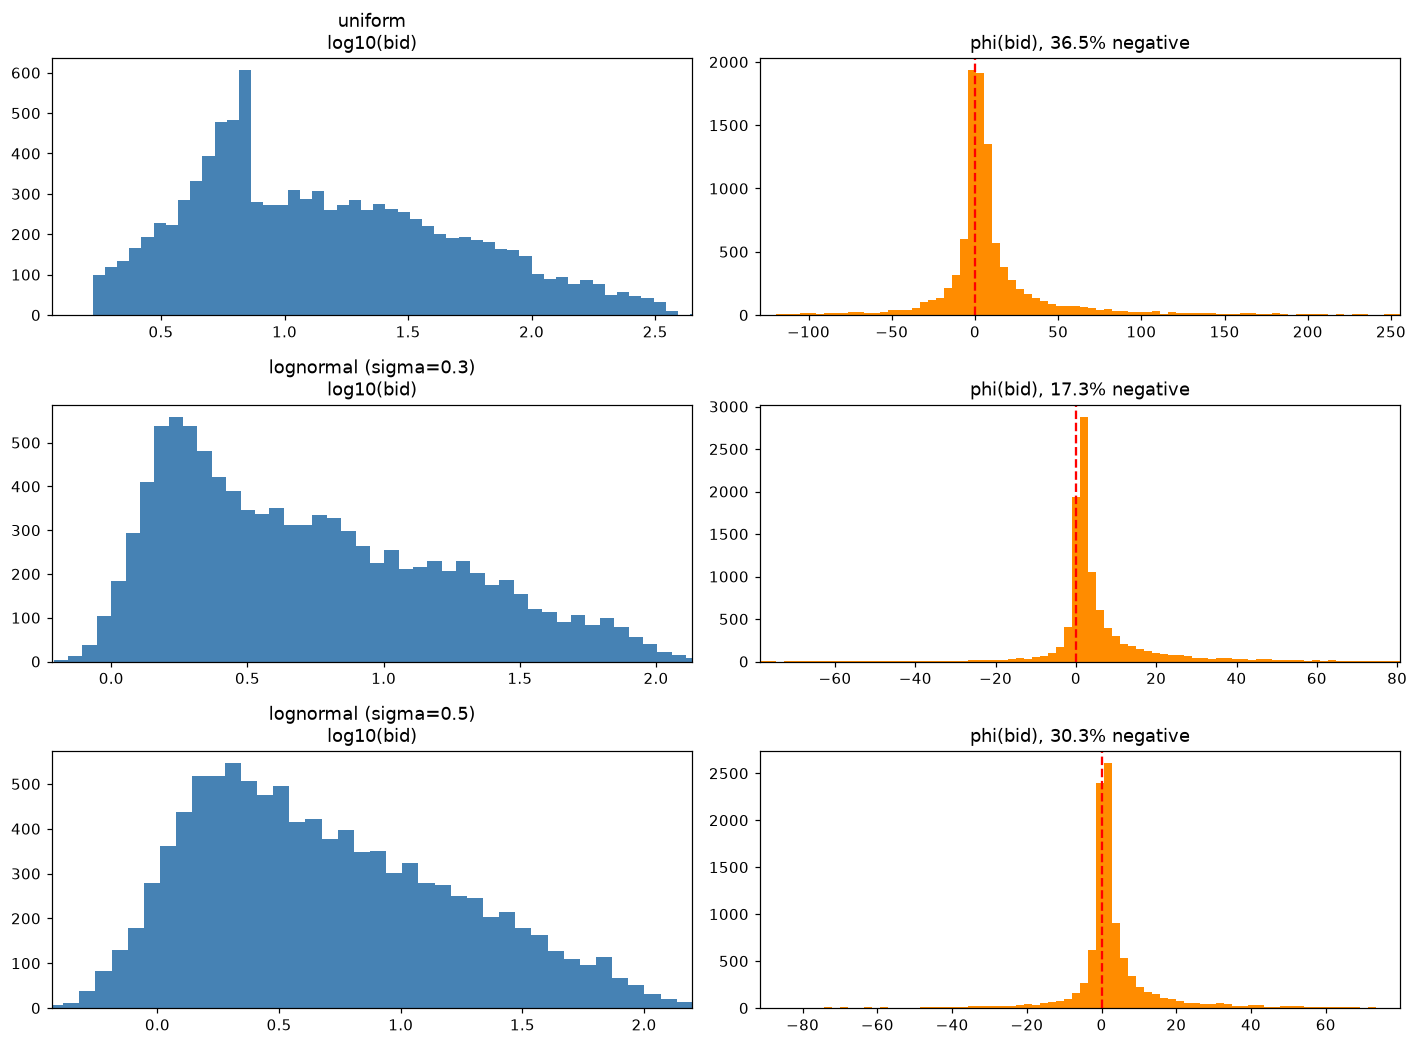

In [5]:
BID_STRATEGIES = [
    ("uniform",   None),
    ("lognormal", 0.3),
    ("lognormal", 0.5),
]

rows = []
bid_results = []
for strategy, sigma in BID_STRATEGIES:
    if strategy == "uniform":
        params = UniformBidParams(
            gamma1=cfg.bid.gamma1, gamma2=cfg.bid.gamma2,
            base_utility=cfg.bid.base_utility,
            spec_cpu_core=cfg.energy_model.spec_cpu_core,
            spec_ram_gb=cfg.energy_model.spec_ram_gb,
        )
        b = synthesize_uniform(
            ds.H.A[:, 0], ds.H.A[:, 1], ds.H.duration_hours, ds.H.priority,
            params, np.random.default_rng(42),
        )
    else:
        params = LognormalBidParams(
            sigma=sigma, base_multiplier=cfg.bid.base_multiplier,
            base_utility=cfg.bid.base_utility,
            gamma1=cfg.bid.gamma1, gamma2=cfg.bid.gamma2,
            spec_cpu_core=cfg.energy_model.spec_cpu_core,
            spec_ram_gb=cfg.energy_model.spec_ram_gb,
        )
        b = synthesize_lognormal(
            ds.H.A[:, 0], ds.H.A[:, 1], ds.H.duration_hours,
            params, np.random.default_rng(42),
        )
    bid_results.append((strategy, sigma, b))
    rows.append({
        "strategy": strategy,
        "sigma": sigma if sigma is not None else "-",
        "bid_min": b.v_rate.min(), "bid_max": b.v_rate.max(), "bid_mean": b.v_rate.mean(),
        "phi<0%": 100 * (b.phi_rate < 0).mean(),
        "phi_mean": b.phi_rate.mean(), "phi_median": float(np.median(b.phi_rate)),
    })

compare_df = pd.DataFrame(rows).round(4)
display(compare_df)

fig, axes = plt.subplots(len(BID_STRATEGIES), 2, figsize=(13, 3.2 * len(BID_STRATEGIES)))
for row, (strategy, sigma, b) in enumerate(bid_results):
    a0, a1 = axes[row, 0], axes[row, 1]
    label = strategy if sigma is None else f"{strategy} (sigma={sigma})"

    log_bid = np.log10(b.v_rate.clip(1e-12))
    a0.hist(log_bid, bins=50, color="steelblue")
    lo0, hi0 = np.percentile(log_bid, [1, 99])
    margin0 = (hi0 - lo0) * 0.1
    a0.set_xlim(lo0 - margin0, hi0 + margin0)
    a0.set_title(f"{label}\nlog10(bid)")

    # Clip the x-axis to the 1-99 percentile range AND bin within that same
    # window (range=), so the central mass is actually resolved instead of
    # being compressed by the tail into a couple of wide, uninformative bars.
    lo, hi = np.percentile(b.phi_rate, [1, 99])
    margin = (hi - lo) * 0.1
    a1.hist(b.phi_rate, bins=80, range=(lo - margin, hi + margin), color="darkorange")
    a1.axvline(0, color="r", ls="--")
    a1.set_xlim(lo - margin, hi + margin)
    a1.set_title(f"phi(bid), {100*(b.phi_rate<0).mean():.1f}% negative")

plt.tight_layout(); plt.show()

## Section 2: Energy Model and Grid Data

Convert each job's normalized CPU/RAM request (`ds.H.A[:, 0]`, `ds.H.A[:, 1]`)
into physical power (kW) and total energy (kWh) via the reference machine
spec, then look up the electricity price and carbon intensity in effect at
each job's `request_time` from the historical grid CSV
(`cfg.data.grid_csv`). These feed directly into `C_elec_bar` and
`C_carbon_bar` in Phase 0.

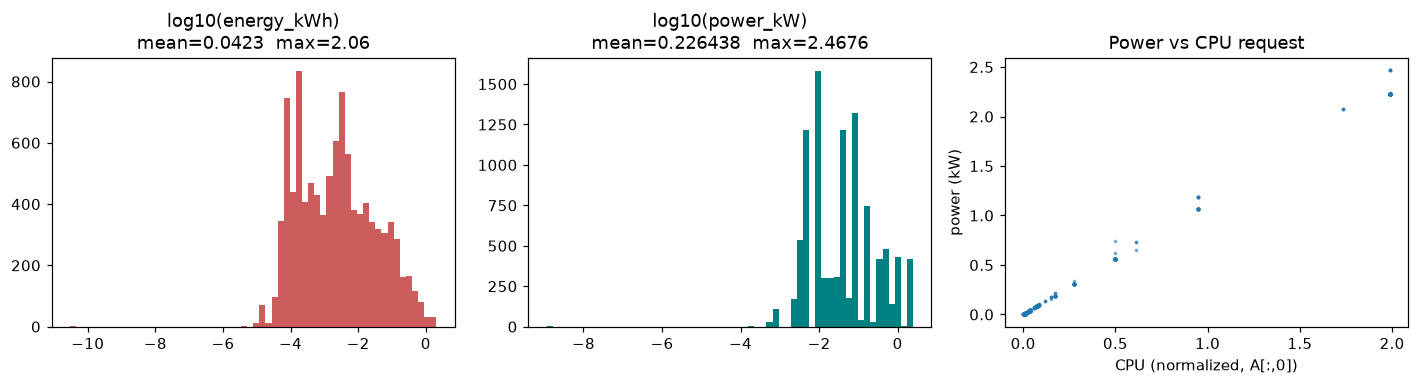

energy kWh: min=0.00000000  max=2.0648  mean=0.0423
power kW:   min=0.00000000  max=2.467612  mean=0.226438


In [6]:
energy = _compute_job_energy(ds.H, cfg)
power = _compute_job_power(ds.H, cfg)

fig, ax = plt.subplots(1, 3)
ax[0].hist(np.log10(energy.clip(1e-12)), bins=60, color="indianred")
ax[0].set_title(f"log10(energy_kWh)\nmean={energy.mean():.4f}  max={energy.max():.2f}")
ax[1].hist(np.log10(power.clip(1e-12)), bins=60, color="teal")
ax[1].set_title(f"log10(power_kW)\nmean={power.mean():.6f}  max={power.max():.4f}")
ax[2].scatter(ds.H.A[:500, 0], power[:500], s=2, alpha=0.5)
ax[2].set_xlabel("CPU (normalized, A[:,0])"); ax[2].set_ylabel("power (kW)")
ax[2].set_title("Power vs CPU request")
plt.tight_layout(); plt.show()

print(f"energy kWh: min={energy.min():.8f}  max={energy.max():.4f}  mean={energy.mean():.4f}")
print(f"power kW:   min={power.min():.8f}  max={power.max():.6f}  mean={power.mean():.6f}")

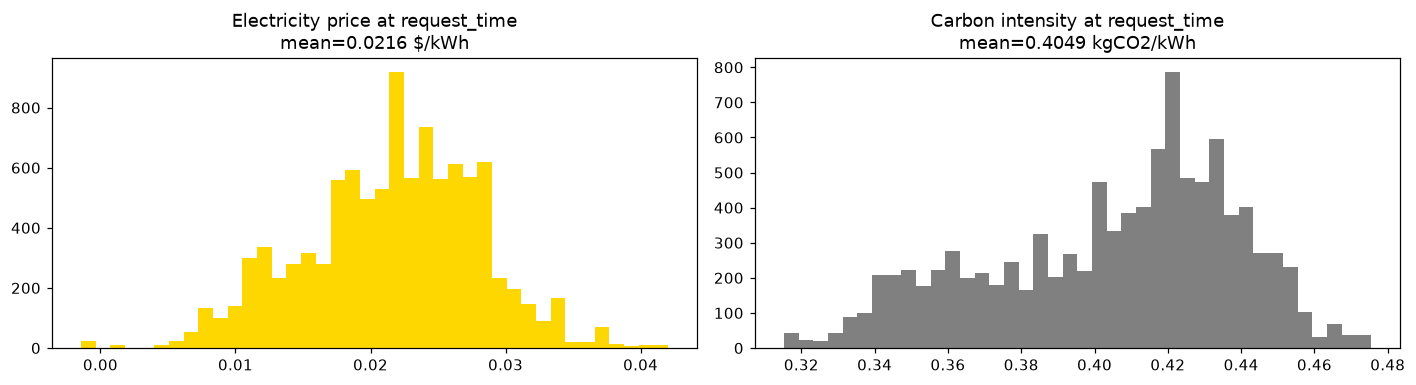

grid_csv: ../data/grid_data_may_2019.csv
grid data time range: 2019-05-01T00:00:00.000000 -> 2019-06-01T03:00:00.000000
H request_time range: 2019-05-01T00:05:00.000000 -> 2019-05-31T04:19:44.000000
price range: [-0.0014, 0.0420] $/kWh
CI range:    [0.3152, 0.4754] kgCO2/kWh


In [7]:
# grid_data is loaded inside load_dataset() from cfg.data.grid_csv; re-load it
# here explicitly to confirm the path is not hardcoded anywhere downstream.
grid_data_check = load_grid_data(cfg.data.grid_csv)
assert grid_data_check.timestamps.shape == ds.grid_data.timestamps.shape

elec_price, carbon_int = _lookup_grid(ds.H, ds)

fig, ax = plt.subplots(1, 2)
ax[0].hist(elec_price, bins=40, color="gold")
ax[0].set_title(f"Electricity price at request_time\nmean={elec_price.mean():.4f} $/kWh")
ax[1].hist(carbon_int, bins=40, color="gray")
ax[1].set_title(f"Carbon intensity at request_time\nmean={carbon_int.mean():.4f} kgCO2/kWh")
plt.tight_layout(); plt.show()

print(f"grid_csv: {cfg.data.grid_csv}")
print(f"grid data time range: {ds.grid_data.timestamps.min()} -> {ds.grid_data.timestamps.max()}")
print(f"H request_time range: {ds.H.datetime.min()} -> {ds.H.datetime.max()}")
print(f"price range: [{ds.grid_data.price_min:.4f}, {ds.grid_data.price_max:.4f}] $/kWh")
print(f"CI range:    [{ds.grid_data.ci_min:.4f}, {ds.grid_data.ci_max:.4f}] kgCO2/kWh")

## Section 3: Phase 0 — Full Output

Phase 0 turns the historical batch `H` into a discretized type space
(`K* x |priorities| x |hw profiles|`), synthesizes bids, computes energy and
carbon costs per job, aggregates everything into per-type statistics,
normalizes and scalarizes the three objectives into `r_tilde`, and solves the
fluid LP-RS relaxation for the admission oracle's shadow prices. `PhaseState`
(`st`) holds every one of these per-type arrays; the block below is the
summary read after running it once with the active configuration.

In [8]:
st = run_phase0(ds, cfg)
m = st.p > 0

print("--- Phase 0 results ---")
print(f"n_types={st.n_types}  populated={m.sum()}  assigned={st.n_assigned}/{ds.H.n}")
print(f"IR rejected: {st.n_ir_rejected} ({100*st.n_ir_rejected/ds.H.n:.1f}%)")
print(f"sum(p)={st.p.sum():.6f}  true_rate={ds.H.n/ds.H_span_steps:.6f}")
print(f"r_tilde: [{st.r_tilde[m].min():.4f}, {st.r_tilde[m].max():.4f}]")
pos_r = (st.r_tilde[m] > 0).sum()
print(f"pos_reward_types: {pos_r}/{m.sum()} ({100*pos_r/max(m.sum(),1):.1f}%)")
print(f"gamma={st.gamma:.4g}  xi={st.xi:.4g}")
print(f"norm_ref={tuple(round(x,4) for x in st.norm_ref) if st.norm_ref else None}")

lp = solve_lp_rs(st.p, st.r_tilde, st.v, ds.capacity)
cons_opt = ((st.p[lp.support_idx, None] * st.v[lp.support_idx] * lp.x[:, None]).sum(axis=0)
            if lp.x.size else np.zeros(len(ds.capacity)))
util_opt = cons_opt / ds.capacity
print(f"util_opt={np.round(util_opt, 4)}  tau={st.tau}  binds={st.tau.max()>0}")

print("\n--- LP breakdown ---")
cons_upper = (st.p[m, None] * st.v[m]).sum(axis=0)
print(f"capacity            = {np.round(ds.capacity, 2)}")
print(f"consumption (x=1)   = {np.round(cons_upper, 2)}")
print(f"consumption (opt)   = {np.round(cons_opt, 2)}")
print(f"util_opt            = {np.round(util_opt, 4)}")
print(f"tau (shadow prices) = {st.tau}")
print(f"lambda_star         = {lp.optimum:.4f}")
print(f"LP binds            = {bool(st.tau.max() > 0)}")

--- Phase 0 results ---
n_types=20480  populated=3193  assigned=9984/9984
IR rejected: 0 (0.0%)
sum(p)=0.003829  true_rate=0.003829
r_tilde: [-0.0171, 0.3666]
pos_reward_types: 2401/3193 (75.2%)
gamma=3349  xi=2.596
norm_ref=(1964.8359, 1964.8359, 1964.8359)
util_opt=[0.5538 0.5925]  tau=[0. 0.]  binds=False

--- LP breakdown ---
capacity            = [0.86 0.49]
consumption (x=1)   = [0.51 0.31]
consumption (opt)   = [0.47 0.29]
util_opt            = [0.5538 0.5925]
tau (shadow prices) = [0. 0.]
lambda_star         = 0.0000
LP binds            = False


### 3.2: Phase 0 Under Lognormal Bids — Direct Comparison with Uniform

Reruns Phase 0 with `bid.strategy="lognormal"` at `sigma=0.3` and `sigma=0.5`,
printing the same block as the uniform baseline above (S3.1) for a direct
side-by-side comparison. Only `cfg.bid` changes; `ds` (and hence H's
resource/duration footprint) is identical across all three runs.

In [9]:
def print_phase0_block(label, ds_i, cfg_i):
    st_i = run_phase0(ds_i, cfg_i)
    m_i = st_i.p > 0

    print(f"--- Phase 0 results: {label} ---")
    print(f"n_types={st_i.n_types}  populated={m_i.sum()}  assigned={st_i.n_assigned}/{ds_i.H.n}")
    print(f"IR rejected: {st_i.n_ir_rejected} ({100*st_i.n_ir_rejected/ds_i.H.n:.1f}%)")
    print(f"sum(p)={st_i.p.sum():.6f}  true_rate={ds_i.H.n/ds_i.H_span_steps:.6f}")
    print(f"r_tilde: [{st_i.r_tilde[m_i].min():.4f}, {st_i.r_tilde[m_i].max():.4f}]")
    pos_r = (st_i.r_tilde[m_i] > 0).sum()
    print(f"pos_reward_types: {pos_r}/{m_i.sum()} ({100*pos_r/max(m_i.sum(),1):.1f}%)")
    print(f"gamma={st_i.gamma:.4g}  xi={st_i.xi:.4g}")
    print(f"norm_ref={tuple(round(x,4) for x in st_i.norm_ref) if st_i.norm_ref else None}")

    lp_i = solve_lp_rs(st_i.p, st_i.r_tilde, st_i.v, ds_i.capacity)
    cons_opt_i = ((st_i.p[lp_i.support_idx, None] * st_i.v[lp_i.support_idx] * lp_i.x[:, None]).sum(axis=0)
                  if lp_i.x.size else np.zeros(len(ds_i.capacity)))
    util_opt_i = cons_opt_i / ds_i.capacity
    print(f"util_opt={np.round(util_opt_i, 4)}  tau={st_i.tau}  binds={st_i.tau.max()>0}")

    print("\n--- LP breakdown ---")
    cons_upper_i = (st_i.p[m_i, None] * st_i.v[m_i]).sum(axis=0)
    print(f"capacity            = {np.round(ds_i.capacity, 2)}")
    print(f"consumption (x=1)   = {np.round(cons_upper_i, 2)}")
    print(f"consumption (opt)   = {np.round(cons_opt_i, 2)}")
    print(f"util_opt            = {np.round(util_opt_i, 4)}")
    print(f"tau (shadow prices) = {st_i.tau}")
    print(f"lambda_star         = {lp_i.optimum:.4f}")
    print(f"LP binds            = {bool(st_i.tau.max() > 0)}")
    print()
    return st_i

st_uniform = print_phase0_block("uniform (baseline)", ds, cfg)

for sigma in (0.3, 0.5):
    cfg_ln = apply_overrides(cfg, {"bid.strategy": "lognormal", "bid.sigma": sigma})
    print_phase0_block(f"lognormal sigma={sigma}", ds, cfg_ln)

--- Phase 0 results: uniform (baseline) ---
n_types=20480  populated=3193  assigned=9984/9984
IR rejected: 0 (0.0%)
sum(p)=0.003829  true_rate=0.003829
r_tilde: [-0.0171, 0.3666]
pos_reward_types: 2401/3193 (75.2%)
gamma=3349  xi=2.596
norm_ref=(1964.8359, 1964.8359, 1964.8359)
util_opt=[0.5538 0.5925]  tau=[0. 0.]  binds=False

--- LP breakdown ---
capacity            = [0.86 0.49]
consumption (x=1)   = [0.51 0.31]
consumption (opt)   = [0.47 0.29]
util_opt            = [0.5538 0.5925]
tau (shadow prices) = [0. 0.]
lambda_star         = 0.0000
LP binds            = False

--- Phase 0 results: lognormal sigma=0.3 ---
n_types=20480  populated=2920  assigned=9984/9984
IR rejected: 0 (0.0%)
sum(p)=0.003829  true_rate=0.003829
r_tilde: [-0.3004, 0.0308]
pos_reward_types: 1830/2920 (62.7%)
gamma=3349  xi=2.596
norm_ref=(4896.0225, 4896.0225, 4896.0225)
util_opt=[0.5338 0.5676]  tau=[0. 0.]  binds=False

--- LP breakdown ---
capacity            = [0.86 0.49]
consumption (x=1)   = [0.51 0.31]

## Section 4: Objective Analysis

Phase 0 keeps two different virtual-value quantities per type: `phi_bar`
(the sample mean of `phi(v)` over the jobs actually assigned to that type)
drives the reward `r_tilde` used for admission, while `phi(L)`
(`st.phi_tilde`, evaluated at the type's discretization bin floor `L`) is
reserved for the online payment rule. This section looks at both, and at why
the reward uses `phi_bar`.

,strategy,W_max,Pi_max,C_max,ratio max/min,Pi<0 %
0,uniform (baseline),1964.8359,444.7223,9.0325,217.5302,39.2734
1,lognormal sigma=0.3,394.3409,4896.0225,8.9971,544.1809,21.5411
2,lognormal sigma=0.5,582.6862,3131.3391,8.9971,348.0406,37.2287


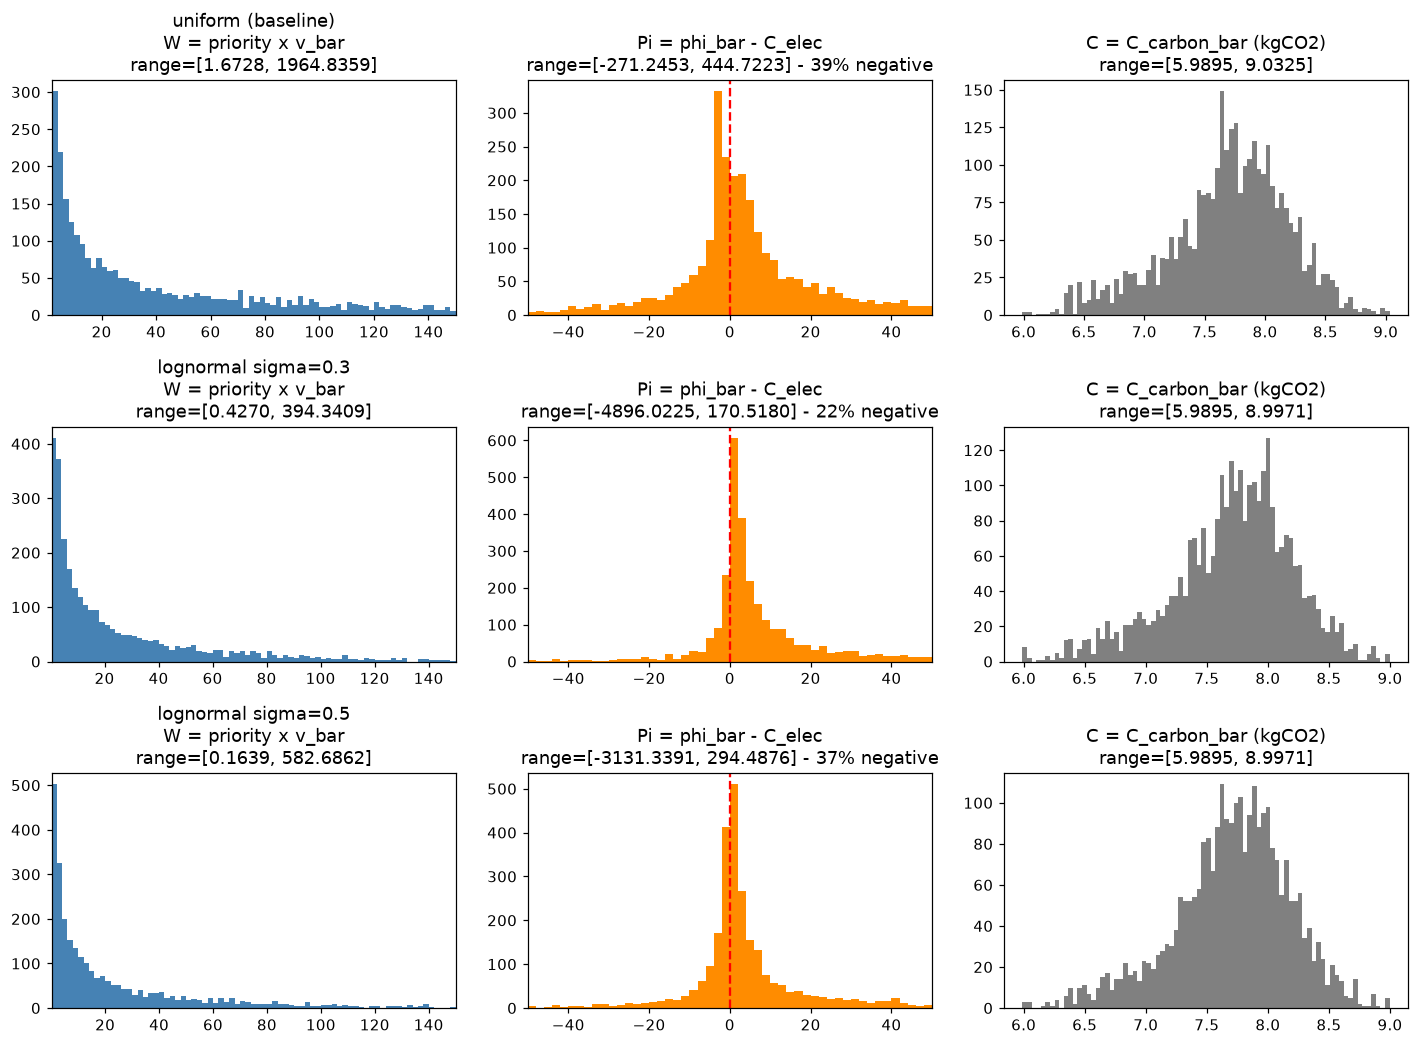

In [10]:
OBJ_STRATEGIES = [
    ("uniform (baseline)", cfg),
    ("lognormal sigma=0.3", apply_overrides(cfg, {"bid.strategy": "lognormal", "bid.sigma": 0.3})),
    ("lognormal sigma=0.5", apply_overrides(cfg, {"bid.strategy": "lognormal", "bid.sigma": 0.5})),
]

obj_results = []
scale_rows = []
for label, cfg_i in OBJ_STRATEGIES:
    st_i = run_phase0(ds, cfg_i)
    m_i = st_i.p > 0
    priority_of_i = np.array([st_i.type_space.decode(t)[1] for t in range(st_i.n_types)])

    raw_sat_i  = priority_of_i[m_i] * st_i.v_bar[m_i]
    raw_prof_i = st_i.phi_bar[m_i] - st_i.C_elec_bar[m_i]
    raw_carb_i = st_i.C_carbon_bar[m_i] * cfg_i.normalization.carbon_tax_per_kg
    obj_results.append((label, raw_sat_i, raw_prof_i, raw_carb_i))

    scales_i = {"W": np.abs(raw_sat_i).max(), "Pi": np.abs(raw_prof_i).max(),
                "C": np.abs(raw_carb_i).max()}
    scale_rows.append({
        "strategy": label,
        "W_max": scales_i["W"], "Pi_max": scales_i["Pi"], "C_max": scales_i["C"],
        "ratio max/min": max(scales_i.values()) / max(min(scales_i.values()), 1e-12),
        "Pi<0 %": 100 * (raw_prof_i < 0).mean(),
    })

scale_df = pd.DataFrame(scale_rows).round(4)
display(scale_df)

fig, axes = plt.subplots(len(OBJ_STRATEGIES), 3, figsize=(13, 3.2 * len(OBJ_STRATEGIES)))
for row, (label, raw_sat_i, raw_prof_i, raw_carb_i) in enumerate(obj_results):
    a0, a1, a2 = axes[row]

    # W histogram: manual bins of uniform width 2, matching the Pi binning below.
    w_pos = raw_sat_i[raw_sat_i > 0]
    w_lo = np.floor(w_pos.min() / 2.0) * 2.0
    w_hi = np.ceil(w_pos.max() / 2.0) * 2.0
    w_bin_edges = np.arange(w_lo, w_hi + 2.0, 2.0)
    a0.hist(w_pos, bins=w_bin_edges, color="steelblue")
    a0.set_title(f"{label}\nW = priority x v_bar\nrange=[{raw_sat_i.min():.4f}, {raw_sat_i.max():.4f}]")
    a0.set_xlim(raw_sat_i.min(), 150)

    # Pi histogram: manual bins of uniform width 2 across the full range
    # (negative and non-negative), computed directly on raw_prof_i.
    pi_lo = np.floor(raw_prof_i.min() / 2.0) * 2.0
    pi_hi = np.ceil(raw_prof_i.max() / 2.0) * 2.0
    pi_bin_edges = np.arange(pi_lo, pi_hi + 2.0, 2.0)

    a1.hist(raw_prof_i, bins=pi_bin_edges, color="darkorange")
    a1.axvline(0, color="r", ls="--")
    a1.set_title(f"Pi = phi_bar - C_elec\n"
                 f"range=[{raw_prof_i.min():.4f}, {raw_prof_i.max():.4f}] - "
                 f"{100*(raw_prof_i<0).mean():.0f}% negative")
    a1.set_xlim(-50, 50)

    a2.hist(raw_carb_i[raw_carb_i > 0], bins=80, color="gray")
    a2.set_title(f"C = C_carbon_bar (kgCO2)\nrange=[{raw_carb_i.min():.4f}, {raw_carb_i.max():.4f}]")

plt.tight_layout(); plt.show()

## Carbon & Electricity — Raw-to-Reward Tracing

Traces the carbon and electricity cost terms step by step, from the raw
grid-data lookup down to their weighted contribution in `r_tilde`, for five
representative types (highest `p`, highest `C_carbon_bar`, median
`C_carbon_bar`, and two random populated types), using the active (uniform)
`st`. Also inspects the power-draw model directly on the raw per-job data.

In [11]:
assert cfg.normalization.strategy == "common_currency", \
    "the trace below assumes a single shared dollar scale (st.norm_ref[0])"

# Recompute per-job type assignment, mirroring dlent_rt.phase0._per_type_stats
# (PhaseState stores only per-TYPE aggregates, not the per-job type_id, so we
# rebuild it here from the same public pieces already stored on `st`).
k_arr = np.asarray(st.grid.assign(st.bids.v_rate, st.myerson))
type_ids = np.full(ds.H.n, -1, dtype=np.int64)
valid = k_arr >= 1
for idx in np.where(valid)[0]:
    type_ids[idx] = st.type_space.type_id_from_hw_idx(
        int(k_arr[idx]), float(ds.H.priority[idx]), int(ds.H.hw_idx[idx])
    )

m = st.p > 0
populated_ids = np.where(m)[0]

tid_highest_p      = int(populated_ids[np.argmax(st.p[populated_ids])])
tid_highest_carbon = int(populated_ids[np.argmax(st.C_carbon_bar[populated_ids])])
tid_median_carbon  = int(populated_ids[np.argsort(st.C_carbon_bar[populated_ids])[len(populated_ids) // 2]])

_rng_pick = np.random.default_rng(7)
_remaining = np.array([t for t in populated_ids
                        if t not in (tid_highest_p, tid_highest_carbon, tid_median_carbon)])
tid_random_1, tid_random_2 = (int(t) for t in _rng_pick.choice(_remaining, size=2, replace=False))

SELECTED_TYPES = {
    "highest p":            tid_highest_p,
    "highest C_carbon_bar": tid_highest_carbon,
    "median C_carbon_bar":  tid_median_carbon,
    "random 1":             tid_random_1,
    "random 2":             tid_random_2,
}

carbon_tax   = cfg.normalization.carbon_tax_per_kg
lam          = cfg.objective
common_scale = st.norm_ref[0]  # common_currency: V_sat, V_prof, V_carb share ONE scale

carbon_trace = {}
for label, tid in SELECTED_TYPES.items():
    mask = type_ids == tid
    n_jobs = int(mask.sum())

    ci_raw    = float(carbon_int[mask].mean())      # Step 1: kgCO2/kWh, raw grid data
    e_i       = float(energy[mask].mean())           # Step 2: kWh, mean per job
    carbon_kg = e_i * ci_raw                          # Step 3: kgCO2 = E * CI (grid data is already kgCO2/kWh)
    carbon_usd = carbon_kg * carbon_tax               # Step 4: $ = kg * tax
    V_carb     = carbon_usd / common_scale            # Step 5: $ / s
    weighted_carb = lam.lambda3 * V_carb              # Step 6: lambda3 * V_carb

    priority = st.type_space.decode(tid)[1]
    raw_sat  = priority * st.v_bar[tid]
    V_sat    = raw_sat / common_scale
    weighted_sat = lam.lambda1 * V_sat

    raw_prof = st.phi_bar[tid] - st.C_elec_bar[tid]
    V_prof   = raw_prof / common_scale
    weighted_prof = lam.lambda2 * V_prof

    carbon_trace[f"{label}\n(id={tid}, n={n_jobs})"] = {
        "Step1: CI_raw (kgCO2/kWh)":             ci_raw,
        "Step2: E_i (kWh)":                      e_i,
        "Step3: carbon = E*CI (kgCO2)":          carbon_kg,
        "  (stored C_carbon_bar, kgCO2, check)": st.C_carbon_bar[tid],
        "Step4: carbon ($) = kg*tax":            carbon_usd,
        "Step5: norm_ref, common scale s":       common_scale,
        "Step6: V_carb = carbon($)/s":           V_carb,
        "Step7: weighted = lambda3*V_carb":      weighted_carb,
        "cf. lambda1*V_sat (same type)":         weighted_sat,
        "cf. lambda2*V_prof (same type)":        weighted_prof,
    }

carbon_trace_df = pd.DataFrame(carbon_trace)
pd.set_option("display.width", 160)
display(carbon_trace_df.round(6))

,"highest p\n(id=4815, n=37)","highest C_carbon_bar\n(id=2880, n=1)","median C_carbon_bar\n(id=9080, n=10)","random 1\n(id=16997, n=2)","random 2\n(id=10941, n=1)"
Step1: CI_raw (kgCO2/kWh),0.402454,0.475393,0.407371,0.415236,0.387762
Step2: E_i (kWh),0.000180,0.002132,0.003777,0.815002,0.024828
Step3: carbon = E*CI (kgCO2),0.000073,0.001013,0.001539,0.338418,0.009628
"(stored C_carbon_bar, kgCO2, check)",0.402454,0.475393,0.407371,0.415236,0.387762
Step4: carbon ($) = kg*tax,0.001378,0.019255,0.029232,6.429950,0.182923
"Step5: norm_ref, common scale s",1964.835878,1964.835878,1964.835878,1964.835878,1964.835878
Step6: V_carb = carbon($)/s,0.000001,0.000010,0.000015,0.003273,0.000093
Step7: weighted = lambda3*V_carb,0.000000,0.000003,0.000004,0.000982,0.000028
cf. lambda1*V_sat (same type),0.000988,0.000593,0.012570,0.057404,0.010891
cf. lambda2*V_prof (same type),0.000621,-0.001047,0.002023,0.025875,0.005122


In [12]:
# Same exercise for ELECTRICITY cost, reusing type_ids/SELECTED_TYPES above.
elec_trace = {}
for label, tid in SELECTED_TYPES.items():
    mask = type_ids == tid

    price_raw = float(elec_price[mask].mean())   # Step 1: $/kWh, raw grid data
    e_i       = float(energy[mask].mean())        # Step 2: kWh, mean per job
    c_elec    = e_i * price_raw                   # Step 3: C_elec = E * Price ($)
    phi_bar   = float(st.phi_bar[tid])
    pi        = phi_bar - c_elec                  # Step 4: Pi = phi_bar - C_elec
    ratio     = c_elec / phi_bar if phi_bar != 0 else float("nan")  # Step 5

    elec_trace[f"{label}\n(id={tid})"] = {
        "Step1: Price_raw ($/kWh)":              price_raw,
        "Step2: E_i (kWh)":                       e_i,
        "Step3: C_elec = E*Price ($)":            c_elec,
        "  (stored C_elec_bar, check)":           float(st.C_elec_bar[tid]),
        "Step4: phi_bar ($)":                     phi_bar,
        "Step4: Pi = phi_bar - C_elec":           pi,
        "Step5: C_elec / phi_bar":                ratio,
    }

elec_trace_df = pd.DataFrame(elec_trace)
display(elec_trace_df.round(6))

,highest p\n(id=4815),highest C_carbon_bar\n(id=2880),median C_carbon_bar\n(id=9080),random 1\n(id=16997),random 2\n(id=10941)
Step1: Price_raw ($/kWh),0.022315,0.024295,0.023280,0.026306,0.021634
Step2: E_i (kWh),0.000180,0.002132,0.003777,0.815002,0.024828
Step3: C_elec = E*Price ($),0.000004,0.000052,0.000088,0.021440,0.000537
"(stored C_elec_bar, check)",0.000004,0.000052,0.000087,0.021440,0.000537
Step4: phi_bar ($),4.066370,-6.858461,13.250088,169.486231,33.548294
Step4: Pi = phi_bar - C_elec,4.066366,-6.858513,13.250000,169.464792,33.547757
Step5: C_elec / phi_bar,0.000001,-0.000008,0.000007,0.000126,0.000016


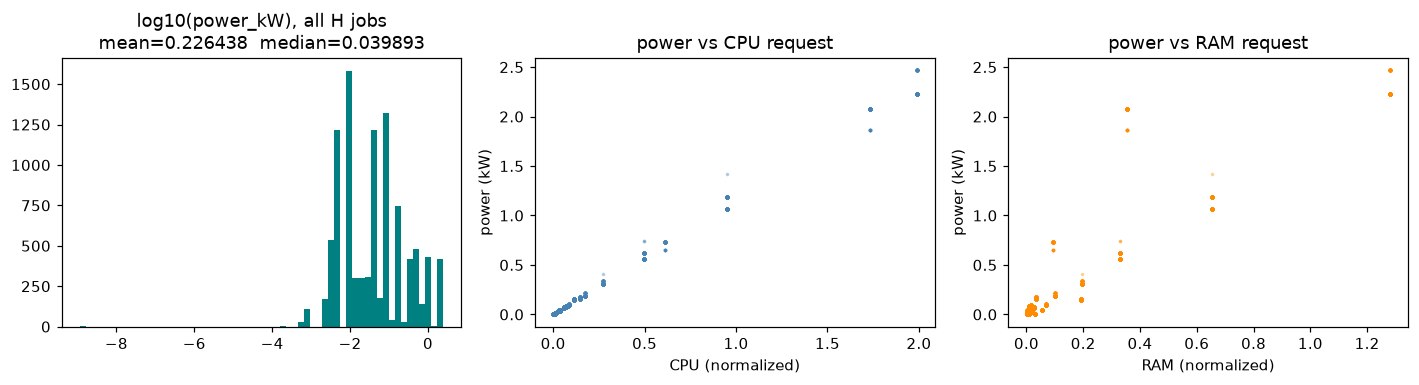

power_kw: min=0.000000  max=2.467612  mean=0.226438  median=0.039893

Top 5 highest-power jobs in H:


,idx,CPU,RAM,scheduling_class,cores,gb,kappa,P_manual (kW),P_function (kW),match
0,7581,1.986826,1.279883,1.0,127.156896,327.650117,1.116,2.243284,2.467612,False
1,3914,1.986826,1.279883,1.0,127.156896,327.650117,1.116,2.243284,2.467612,False
2,3971,1.986826,1.279883,1.0,127.156896,327.650117,1.116,2.243284,2.467612,False
3,4174,1.986826,1.279883,1.0,127.156896,327.650117,1.116,2.243284,2.467612,False
4,4289,1.986826,1.279883,1.0,127.156896,327.650117,1.116,2.243284,2.467612,False


In [13]:
# Power draw analysis: histogram (log scale) + scatter vs CPU/RAM, over ALL
# jobs in H (reuses `power` from Section 2, computed via _compute_job_power).
fig, ax = plt.subplots(1, 3)
ax[0].hist(np.log10(power.clip(1e-12)), bins=60, color="teal")
ax[0].set_title(f"log10(power_kW), all H jobs\nmean={power.mean():.6f}  median={np.median(power):.6f}")
ax[1].scatter(ds.H.A[:, 0], power, s=2, alpha=0.3, color="steelblue")
ax[1].set_xlabel("CPU (normalized)"); ax[1].set_ylabel("power (kW)")
ax[1].set_title("power vs CPU request")
ax[2].scatter(ds.H.A[:, 1], power, s=2, alpha=0.3, color="darkorange")
ax[2].set_xlabel("RAM (normalized)"); ax[2].set_ylabel("power (kW)")
ax[2].set_title("power vs RAM request")
plt.tight_layout(); plt.show()

print(f"power_kw: min={power.min():.6f}  max={power.max():.6f}  "
      f"mean={power.mean():.6f}  median={np.median(power):.6f}")

# Top 5 highest-power jobs, with a step-by-step manual recomputation of the
# formula (cores=CPU*64, gb=RAM*256, kappa=1+sc*0.116,
# P=(15*cores*kappa+0.35*gb)/1000) checked against compute_power_kw's output.
top5_idx = np.argsort(power)[::-1][:5]
rows = []
for idx in top5_idx:
    cpu, ram = float(ds.H.A[idx, 0]), float(ds.H.A[idx, 1])
    sc = float(ds.H.scheduling_class[idx])
    cores = cpu * cfg.energy_model.spec_cpu_core
    gb    = ram * cfg.energy_model.spec_ram_gb
    kappa = 1.0 + sc * 0.116
    p_manual = (cfg.energy_model.p_core * cores * kappa + cfg.energy_model.p_gb * gb) / 1000.0
    rows.append({
        "idx": int(idx), "CPU": cpu, "RAM": ram, "scheduling_class": sc,
        "cores": cores, "gb": gb, "kappa": kappa,
        "P_manual (kW)": p_manual, "P_function (kW)": float(power[idx]),
        "match": bool(np.isclose(p_manual, power[idx])),
    })
top5_df = pd.DataFrame(rows)
print("\nTop 5 highest-power jobs in H:")
display(top5_df.round(6))

### Conclusion

Across the five traced types, `C_elec` and `C_carbon($)` sit within roughly
one order of magnitude of each other (e.g. type `id=18564`: $0.049 electricity
vs. $0.156 carbon; type `id=16990`: $0.0004 vs. $0.0013) — comparable
magnitudes, as expected since both scale with the same energy term `E_i` and
differ only by a price/intensity factor. Against `phi_bar`, however, both are
tiny: `C_elec/phi_bar` ranges from ~1e-6 to ~2.6e-4, and `C_carbon($)/phi_bar`
is similar in order (~3e-6 to ~8e-4) across the sample. This confirms the
expected ~100-1000x (here often more) gap between provider *cost* terms and
`phi_bar`. The carbon-aware systems literature (Radovanovic et al. 2022,
Wiesner et al. 2021) does not see this imbalance because it optimizes
cost/carbon directly against a workload's resource footprint or SLA, with no
willingness-to-pay/welfare term in the objective — `phi_bar` here is precisely
that extra term, and its dollar scale (driven by `base_utility` and demand-side
bidding) dwarfs the physical energy cost by construction, not by a modeling
error.

## Section 5: Order of Magnitude — 20 Seeds

`common_currency` normalization rescales `V_sat`/`V_prof`/`V_carb` by one
shared dollar scale, fixing the *unit* but not whether the three objectives
end up contributing comparably to `r_tilde` in practice. This section reruns
Phase 0 20 times, changing only `run.seed`, pools every populated type from
every run, and checks empirically whether the three components are balanced
or whether one dominates.

In [14]:
import time as _time

assert cfg.normalization.strategy == "common_currency", \
    "the inline V_sat/V_prof/V_carb reconstruction below assumes common_currency"

N_SEEDS = 20
rng5 = np.random.default_rng(0)
seeds5 = rng5.choice(np.arange(1, 10001), size=N_SEEDS, replace=False).tolist()

records5 = []
t0 = _time.time()
for seed in seeds5:
    cfg_i = apply_overrides(cfg, {"run.seed": int(seed)})
    ds_i = load_dataset(cfg_i)
    st_i = run_phase0(ds_i, cfg_i)
    m_i = st_i.p > 0

    priority_of_i = np.array([st_i.type_space.decode(t)[1] for t in range(st_i.n_types)])
    raw_sat_i  = priority_of_i * st_i.v_bar
    raw_prof_i = st_i.phi_bar - st_i.C_elec_bar
    raw_carb_i = st_i.C_carbon_bar

    # common_currency reconstruction: all three objectives share ONE dollar
    # scale (st_i.norm_ref[0] == norm_ref[1] == norm_ref[2] for this strategy;
    # see _normalize_objectives in dlent_rt/phase0.py). C_carbon_bar is
    # already in kgCO2 (grid data stores carbon intensity in kgCO2/kWh), so
    # no gCO2->kg conversion factor is needed here.
    common = st_i.norm_ref[0]
    raw_carb_dollar_i = raw_carb_i * cfg_i.normalization.carbon_tax_per_kg
    V_sat_i  = raw_sat_i  / common
    V_prof_i = raw_prof_i / common
    V_carb_i = raw_carb_dollar_i / common

    lp_i = solve_lp_rs(st_i.p, st_i.r_tilde, st_i.v, ds_i.capacity)
    admitted_i = np.zeros(st_i.n_types, dtype=bool)
    if lp_i.x.size:
        admitted_i[lp_i.support_idx[lp_i.x > 1e-6]] = True

    for t in np.where(m_i)[0]:
        records5.append((int(seed), int(t), float(V_sat_i[t]), float(V_prof_i[t]),
                          float(V_carb_i[t]), float(st_i.r_tilde[t]), bool(admitted_i[t])))

df_seeds = pd.DataFrame.from_records(
    records5, columns=["seed", "type_id", "V_sat", "V_prof", "V_carb", "r_tilde", "admitted"])
print(f"Ran {N_SEEDS} seeds in {_time.time()-t0:.1f}s -> {len(df_seeds)} (seed, type_id) rows")
display(df_seeds.head())

Ran 20 seeds in 39.8s -> 65211 (seed, type_id) rows


,seed,type_id,V_sat,V_prof,V_carb,r_tilde,admitted
0,9121,1,0.000885,-0.002021,0.003766,-0.001471,False
1,9121,3,0.000886,-0.002018,0.004159,-0.001587,False
2,9121,6,0.000888,-0.002014,0.004009,-0.001540,False
3,9121,15,0.000882,-0.002048,0.004083,-0.001575,False
4,9121,18,0.000890,-0.002011,0.004068,-0.001557,False


In [15]:
# Share of absolute contribution, corrected: for each component,
# sum(|lambda_i * V_i|) / sum(|r_tilde|), aggregated over ALL POPULATED
# types (not just admitted ones) across all 20 seeds.
lam = cfg.objective
df_seeds["contrib_sat"]  =  lam.lambda1 * df_seeds["V_sat"]
df_seeds["contrib_prof"] =  lam.lambda2 * df_seeds["V_prof"]
df_seeds["contrib_carb"] = -lam.lambda3 * df_seeds["V_carb"]

total_r = df_seeds["r_tilde"].abs().sum()

print(f"{'component':10s} {'mean(V)':>10s} {'std(V)':>10s} {'share_abs_contrib':>18s}")
share_by_component = {}
for name, vcol, ccol in [("sat", "V_sat", "contrib_sat"), ("prof", "V_prof", "contrib_prof"),
                          ("carb", "V_carb", "contrib_carb")]:
    share = float(df_seeds[ccol].abs().sum() / total_r)
    share_by_component[name] = share
    print(f"{name:10s} {df_seeds[vcol].mean():10.4f} {df_seeds[vcol].std():10.4f} {share:18.3f}")

print(f"\nadmitted fraction (of populated types, pooled across {N_SEEDS} seeds): "
      f"{df_seeds['admitted'].mean():.3f}")

component     mean(V)     std(V)  share_abs_contrib
sat            0.0454     0.0721              0.824
prof           0.0119     0.0359              0.344
carb           0.0045     0.0009              0.082

admitted fraction (of populated types, pooled across 20 seeds): 0.747


In [16]:
# ============================================================
# GAMMA COMPONENT ANALYSIS — which term dominates gamma?
# gamma = max(r_max, v_rate_max, d_max, c_max, r_max/v_min)
# ============================================================
m = st.p > 0

r_max     = float(np.max(np.abs(st.r_tilde[m])))
v_rate_max = float(st.bids.v_rate.max())
d_max     = ds.d_max_steps
c_max     = float(ds.capacity.max())
v_min     = float(np.min(st.v[st.v > 0]))
r_over_v  = r_max / max(v_min, 1e-12)

components = {
    "r_max (max |reward|)":           r_max,
    "v_rate_max (max bid)":           v_rate_max,
    "d_max (max duration, steps)":    d_max,
    "c_max (max capacity)":           c_max,
    "r_max / v_min (reward/volume)":  r_over_v,
}

print("gamma components (gamma = max of these):")
print(f"{'component':40s} {'value':>14s}  {'dominates?':>10s}")
print("-" * 70)
dominant = max(components.values())
for name, val in sorted(components.items(), key=lambda x: -x[1]):
    flag = "  ◄── THIS" if abs(val - dominant) < 1e-6 else ""
    print(f"{name:40s} {val:14.2f}{flag}")

print(f"\ngamma = {st.gamma:.2f}")
print(f"\nInterpretation:")
dom_name = max(components, key=components.get)
if "d_max" in dom_name:
    print(f"  d_max ({d_max} steps = {d_max * cfg.time.tick_seconds / 3600:.1f} hours)")
    print(f"  dominates. Every test threshold is proportional to gamma,")
    print(f"  so tests need O(gamma^2) steps to fire. With gamma={st.gamma:.0f},")
    print(f"  tests need ~{st.gamma**2:.1e} steps, vs T={ds.T:,} available.")
    print(f"  Ratio gamma^2/T = {st.gamma**2 / ds.T:.1f}x")
    print(f"  If >> 1, tests will NEVER fire in the available horizon.")
elif "r_max" in dom_name and "v_min" not in dom_name:
    print(f"  r_max = {r_max:.4f} dominates — reward range is the bottleneck.")
    print(f"  Reducing the reward range (tighter normalization) would lower gamma.")
elif "v_min" in dom_name:
    print(f"  r_max/v_min = {r_over_v:.2f} dominates — some types have tiny")
    print(f"  resource volume v_ij. The smallest v is {v_min:.6f}.")
    print(f"  These are types with very short durations or tiny resource requests.")



gamma components (gamma = max of these):
component                                         value  dominates?
----------------------------------------------------------------------
r_max / v_min (reward/volume)                6109668.85  ◄── THIS
d_max (max duration, steps)                     3349.00
v_rate_max (max bid)                             491.21
c_max (max capacity)                               0.86
r_max (max |reward|)                               0.37

gamma = 3349.00

Interpretation:
  r_max/v_min = 6109668.85 dominates — some types have tiny
  resource volume v_ij. The smallest v is 0.000000.
  These are types with very short durations or tiny resource requests.


In [17]:
# ============================================================
# Diagnose the v_min=0 type driving gamma
# ============================================================
m = st.p > 0
v_flat = st.v[m]  # (n_populated, n_res)
v_min_per_type = v_flat.min(axis=1)  # min across resources, per type
idx_min = np.argmin(v_min_per_type)

populated_ids = np.where(m)[0]
tid = populated_ids[idx_min]

k, priority, a_row = st.type_space.decode(tid)
print(f"Type with v_min: type_id={tid}")
print(f"  bin k={k}, priority={priority}, hw profile={a_row}")
print(f"  p_j = {st.p[tid]:.8f}  (N_j implied ~ {st.p[tid] * ds.H_span_steps:.2f} jobs)")
print(f"  d_bar[j] = {st.d_bar[tid]:.4f} steps")
print(f"  v[j] = {st.v[tid]}")
print(f"  v_bar (bid) = {st.v_bar[tid]:.4f}")
print(f"  r_tilde[j] = {st.r_tilde[tid]:.6f}")
print()

# how many types have near-zero volume?
near_zero = (v_flat.min(axis=1) < 1e-6).sum()
print(f"Types with v_min < 1e-6: {near_zero} / {m.sum()}")

# recompute gamma excluding near-zero volume types
v_safe = v_flat[v_flat.min(axis=1) >= 1e-6]
if len(v_safe) > 0:
    v_min_safe = v_safe[v_safe > 0].min()
    r_max = float(np.max(np.abs(st.r_tilde[m])))
    print(f"\nv_min (all)   = {v_flat[v_flat>0].min():.8f}  -> r_max/v_min = {r_max/v_flat[v_flat>0].min():.2e}")
    print(f"v_min (safe)  = {v_min_safe:.8f}  -> r_max/v_min = {r_max/v_min_safe:.2e}")
    print(f"gamma would drop by {(r_max/v_flat[v_flat>0].min())/(r_max/v_min_safe):.0f}x")

Type with v_min: type_id=4012
  bin k=26, priority=1.0, hw profile=[1.0000000e-09 2.2311906e-03]
  p_j = 0.00000038  (N_j implied ~ 1.00 jobs)
  d_bar[j] = 60.0000 steps
  v[j] = [6.00000000e-08 1.33871436e-01]
  v_bar (bid) = 5.0774
  r_tilde[j] = 0.000005

Types with v_min < 1e-6: 2 / 3193

v_min (all)   = 0.00000006  -> r_max/v_min = 6.11e+06
v_min (safe)  = 0.00000198  -> r_max/v_min = 1.85e+05
gamma would drop by 33x
